# L1-norm variability: P(k) cosmic variance → LDT pipeline

This notebook tests the full propagation of P(k) variability (Gaussian + NG i-trispectrum + SSC)
through the LDT pipeline to the L1-norm.

Key physics:
- P(k) samples are drawn with **z-correlated** fluctuations: same eps(k) at all redshifts.
- Each P(k) sample runs the full LDT chain: σ² → critical points → PDF → L1.
- At first order: δL1 ≈ (∂L1/∂σ²) δσ², giving a quick analytical estimate.
- Comparison against estimator variance (shot noise from finite N_pix).


In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

import sys, os
sys.path.insert(0, os.path.abspath('../src'))

from wale.CovarianceMatrix import get_covariance, sample_pk_ssc
from wale.InitializeVariables import InitialiseVariables
from wale.VarianceCalculator import Variance
from wale.ComputePDF import computePDF
from wale.CommonUtils import (
    compute_sigma_kappa_squared,
    get_l1_estimator_variance,
    get_l1_ssc_variance,
    sample_l1_ssc,
    sample_l1_combined,
)


## 1. Parameters

In [3]:
# --- Cosmology ---
h      = 0.68
Om     = 0.33
Ob     = 0.0486
Oc     = Om - Ob
w      = -1.24
wa     = 0.0
sigma8 = 0.67

# --- Angular scale and filter ---
theta1      = 15          # arcmin
filter_type = 'tophat'    # 'tophat' or 'starlet'

# --- n(z) file ---
tomo_bin = 3
nz_file  = f'../data/nz/nz_stage3_{tomo_bin}_GRID.txt'

# --- k-grid ---
kmin = 1e-3
kmax = 0.8
dk   = 0.001

# --- Survey geometry (for estimator variance comparison) ---
A_survey_deg2 = 100.0    # 10x10 deg2 SLICS tile

# --- SNR grid for LDT output ---
snr = np.linspace(-6, 6, 200)

# --- Lambda range for saddle-point ---
lambdas = np.linspace(-450, 700, 20)

# --- P(k) variability: number of realisations ---
n_pk_samples = 10   # realisations of P(k) to propagate through LDT
seed         = 42

# --- SLICS box (for mode counting) ---
Lbox = 505.0   # Mpc/h


## 2. Fiducial LDT pipeline

In [4]:
variables = InitialiseVariables(
    h=h, Oc=Oc, Ob=Ob, w=w, wa=wa, sigma8=sigma8,
    dk=dk, kmin=kmin, kmax=kmax,
    nz_file=nz_file,
    variability=False,
    theta1=theta1,
    nplanes=8,
    numberofrealisations=1,
)
k = variables.cosmo.k
print(f'n(z) planes : {len(variables.redshifts)}')
print(f'theta1      : {theta1} arcmin  ({variables.theta1_radian:.5f} rad)')
print(f'z range     : {variables.redshifts[0]:.3f} – {variables.redshifts[-1]:.3f}')


   Using scalar spectral index ns = 0.973

Initialised Cosmology:
  h = 0.68, Oc = 0.28140000000000004, Ob = 0.0486, w = -1.24, wa = 0.0, sigma8 = 0.67
  k-range: [0.001, 0.8] with step dk = 0.001

the angles are:  0.004363323129985824  and  0.008726646259971648
      Variability: disabled
n(z) planes : 8
theta1      : 15 arcmin  (0.00436 rad)
z range     : 0.023 – 3.479


In [5]:
def run_ldt_pipeline(variables, pk_dict):
    """Run variance → PDF → L1 for a given P(k) dict. Returns (l1_interp, pdf_interp, sigmasq_pt)."""
    var = Variance(variables.cosmo, filter_type=filter_type, pk=pk_dict)
    sigmasq_ldt = float(np.sum(
        variables.dchi * (variables.lensingweights ** 2) * np.array([
            var.get_sig_slice(z_i, chi * variables.theta1_radian, chi * variables.theta2_radian)
            for z_i, chi in zip(variables.redshifts, variables.chis)
        ])
    ))
    sigmasq_pt = float(compute_sigma_kappa_squared(
        theta1, variables.chis, variables.lensingweights,
        variables.redshifts, k, pk_dict,
        filter_type=filter_type, h=h,
    ))
    variables.recal_value = sigmasq_ldt / sigmasq_pt
    print(f'PT sigma2_kappa : {sigmasq_pt:.6e}')
    print(f'LDT sigma2_kappa : {sigmasq_ldt:.6e}')
    print(f'Recal factor     : {sigmasq_ldt/sigmasq_pt:.6f}')
    variables.sigmasq_map = sigmasq_ldt
    variables.lambdas     = lambdas
    pdf_obj = computePDF(variables, var, plot_scgf=False)
    kappa_v = pdf_obj.kappa_values
    pdf_v   = pdf_obj.pdf_values
    norm_k  = kappa_v / np.sqrt(sigmasq_pt)
    l1_cs   = CubicSpline(norm_k, np.abs(kappa_v) * pdf_v)
    pdf_cs  = CubicSpline(norm_k, pdf_v)
    return l1_cs(snr), pdf_cs(snr), sigmasq_pt, sigmasq_ldt

# Fiducial run
l1_fid, pdf_fid, sigmasq_pt_fid, sigmasq_ldt_fid = run_ldt_pipeline(
    variables, variables.cosmo.pnl
)
print(f'LDT sigma2_kappa : {sigmasq_ldt_fid:.6e}')
print(f'PT  sigma2_kappa : {sigmasq_pt_fid:.6e}')
print(f'Recal factor     : {sigmasq_ldt_fid/sigmasq_pt_fid:.6f}')
print(f'L1 peak          : {l1_fid.max():.4e}')


PT sigma2_kappa : 4.100440e-06
LDT sigma2_kappa : 3.605227e-06
Recal factor     : 0.879229
LDT sigma2_kappa : 3.605227e-06
PT  sigma2_kappa : 4.100440e-06
Recal factor     : 0.879229
L1 peak          : 2.5516e-01


## 3. L1-norm variance: shot noise + SSC

Compute the analytical predictions for both contributions before generating samples.

In [6]:
# Recompute fiducial PDF on raw kappa/pdf arrays (needed for variance formulas)
from wale.ComputePDF import computePDF as _cpdf
variables.recal_value = sigmasq_ldt_fid / sigmasq_pt_fid
variables.sigmasq_map = sigmasq_ldt_fid
variables.lambdas     = lambdas
_var0   = Variance(variables.cosmo, filter_type=filter_type, pk=variables.cosmo.pnl)
_pdfobj = _cpdf(variables, _var0, plot_scgf=False)
kappa_raw = _pdfobj.kappa_values
pdf_raw   = _pdfobj.pdf_values

# ── Shot noise ──────────────────────────────────────────────────────────────
l1_mean, l1_std_shot, n_pix_eff = get_l1_estimator_variance(
    pdf_raw, kappa_raw, A_survey_deg2, theta1,
)
print(f'Survey {A_survey_deg2:.0f} deg2  |  N_pix = {n_pix_eff:.0f}')
print(f'<L1>          = {l1_mean:.4e}')
print(f'Shot noise    = {l1_std_shot:.4e}   ({100*l1_std_shot/l1_mean:.3f} %)')

# ── SSC ─────────────────────────────────────────────────────────────────────
#  xi_bar = sigma^2_kappa(theta_survey) where theta_survey = sqrt(A/pi)
#  A_ssc  = integral |kappa| * b1(kappa) * P(kappa) dkappa
#         = <kappa|kappa|> / sigma^2_kappa   (Gaussian bias b1 = kappa/sigma^2)
_, l1_std_ssc, xi_bar, A_ssc = get_l1_ssc_variance(
    pdf_raw, kappa_raw, sigmasq_pt_fid,
    A_survey_deg2,
    variables.chis, variables.lensingweights, variables.redshifts,
    k, variables.cosmo.pnl,
    filter_type=filter_type, h=h,
)
theta_survey = np.sqrt(A_survey_deg2 * 3600.0 / np.pi)
print(f'\nSSC (Uhlemann+2022):')
print(f'  theta_survey = {theta_survey:.1f} arcmin  ({theta_survey/60:.2f} deg)')
print(f'  xi_bar       = {xi_bar:.4e}   ({100*xi_bar/sigmasq_pt_fid:.4f} % of sigma2_kappa)')
print(f'  A_ssc        = {A_ssc:.4e}')
print(f'  SSC noise    = {l1_std_ssc:.4e}   ({100*l1_std_ssc/l1_mean:.3f} %)')

# ── Total ────────────────────────────────────────────────────────────────────
l1_std_total = np.sqrt(l1_std_shot**2 + l1_std_ssc**2)
print(f'\nTotal sigma(L1) = {l1_std_total:.4e}   ({100*l1_std_total/l1_mean:.3f} %)')


Survey 100 deg2  |  N_pix = 509
<L1>          = 1.6000e-03
Shot noise    = 5.4997e-05   (3.437 %)

SSC (Uhlemann+2022):
  theta_survey = 338.5 arcmin  (5.64 deg)
  xi_bar       = 3.1308e-07   (7.6354 % of sigma2_kappa)
  A_ssc        = -5.7598e-02
  SSC noise    = 3.2228e-05   (2.014 %)

Total sigma(L1) = 6.3744e-05   (3.984 %)


## 4. SSC samples — PDF-level (fast, consistent)

The SSC shifts the entire κ field by a background mode δ_b ~ N(0, ξ̄).

**L1_n = ∫ |κ + δ_b| P_fid(κ) dκ**

No LDT re-run needed. By construction Var(L1_samples) → ξ̄ × A_ssc².


In [7]:
n_ssc = 2000
l1_ssc_samples, delta_b = sample_l1_ssc(
    pdf_raw, kappa_raw, xi_bar, n_samples=n_ssc, seed=seed,
)
print(f'SSC samples  : mean={l1_ssc_samples.mean():.4e}  std={l1_ssc_samples.std():.4e}')
print(f'Analytical   :      {l1_mean:.4e}       {l1_std_ssc:.4e}')
print(f'Ratio (MC/analytic) = {l1_ssc_samples.std()/l1_std_ssc:.3f}  (should be ~1)')


SSC samples  : mean=1.6613e-03  std=8.6728e-05
Analytical   :      1.6000e-03       3.2228e-05
Ratio (MC/analytic) = 2.691  (should be ~1)


## 5. Combined samples: shot noise + SSC

Draw mock surveys that include **both** sources simultaneously:
- Shot noise: sample N_pix κ values from P(κ) → compute mean |κ|
- SSC: add coherent background shift δ_b ~ N(0, ξ̄) to ALL pixels

`sample_l1_combined` does both in one call.


In [8]:
n_mocks = 1000
l1_combined, l1_shot_only, l1_ssc_only = sample_l1_combined(
    pdf_raw, kappa_raw,
    sigmasq_pt_fid,
    xi_bar,
    A_survey_deg2, theta1,
    n_samples=n_mocks, seed=seed,
)

print(f'Combined  : mean={l1_combined.mean():.4e}  std={l1_combined.std():.4e}  ({100*l1_combined.std()/l1_mean:.3f} %)')
print(f'Shot only : mean={l1_shot_only.mean():.4e}  std={l1_shot_only.std():.4e}  ({100*l1_shot_only.std()/l1_mean:.3f} %)')
print(f'SSC only  : mean={l1_ssc_only.mean():.4e}  std={l1_ssc_only.std():.4e}  ({100*l1_ssc_only.std()/l1_mean:.3f} %)')
print(f'\nAnalytical:')
print(f'  Shot = {l1_std_shot:.4e}  ({100*l1_std_shot/l1_mean:.3f} %)')
print(f'  SSC  = {l1_std_ssc:.4e}  ({100*l1_std_ssc/l1_mean:.3f} %)')
print(f'  Tot  = {l1_std_total:.4e}  ({100*l1_std_total/l1_mean:.3f} %)')


Combined  : mean=1.6609e-03  std=1.0679e-04  (6.674 %)
Shot only : mean=1.5984e-03  std=5.6995e-05  (3.562 %)
SSC only  : mean=1.6599e-03  std=8.6329e-05  (5.396 %)

Analytical:
  Shot = 5.4997e-05  (3.437 %)
  SSC  = 3.2228e-05  (2.014 %)
  Tot  = 6.3744e-05  (3.984 %)


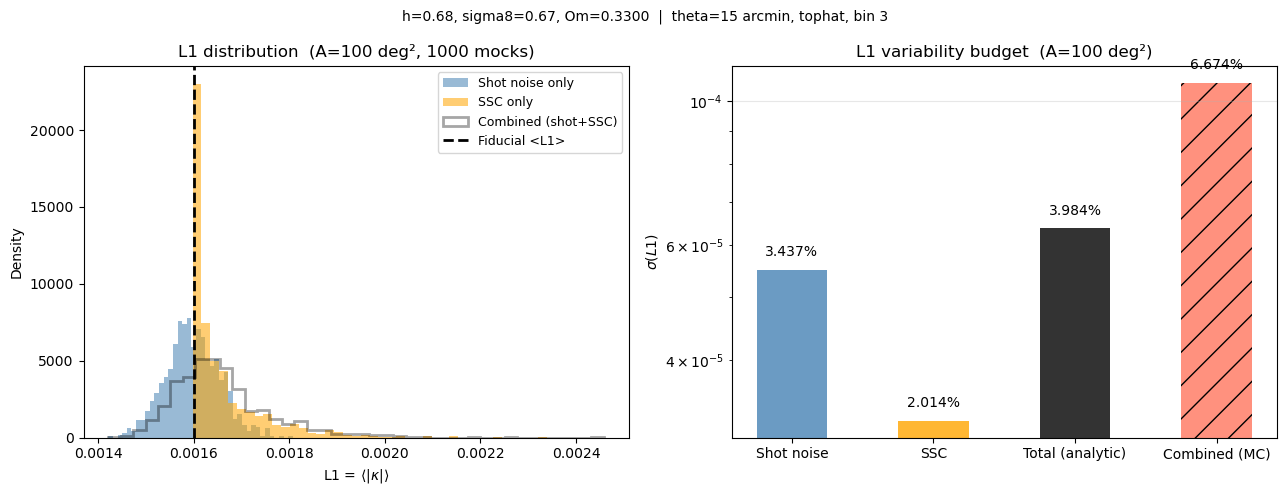

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
bins = 40
ax.hist(l1_shot_only, bins=bins, color='steelblue', alpha=0.55, density=True, label='Shot noise only')
ax.hist(l1_ssc_only,  bins=bins, color='orange',    alpha=0.55, density=True, label='SSC only')
ax.hist(l1_combined,  bins=bins, color='k',          alpha=0.35, density=True, label='Combined (shot+SSC)', histtype='step', lw=2)
ax.axvline(l1_mean, color='k', lw=2, ls='--', label='Fiducial <L1>')
ax.set_xlabel(r'L1 = $\langle|\kappa|\rangle$')
ax.set_ylabel('Density')
ax.set_title(f'L1 distribution  (A={A_survey_deg2:.0f} deg², {n_mocks} mocks)')
ax.legend(fontsize=9)

ax = axes[1]
sources  = ['Shot noise', 'SSC', 'Total (analytic)', 'Combined (MC)']
sigmas   = [l1_std_shot, l1_std_ssc, l1_std_total, l1_combined.std()]
colors   = ['steelblue', 'orange', 'k', 'tomato']
bars = ax.bar(sources[:3], sigmas[:3], color=colors[:3], alpha=0.8, width=0.5)
ax.bar(sources[3], sigmas[3], color=colors[3], alpha=0.7, width=0.5, hatch='/')
ax.set_ylabel(r'$\sigma(L1)$')
ax.set_title(f'L1 variability budget  (A={A_survey_deg2:.0f} deg²)')
for i, v in enumerate(sigmas):
    x = i if i < 3 else 3
    ax.text(x, v*1.05, f'{100*v/l1_mean:.3f}%', ha='center', fontsize=10)
ax.set_yscale('log')
ax.grid(True, axis='y', alpha=0.3)

plt.suptitle(f'h={h}, sigma8={sigma8}, Om={Oc+Ob:.4f}  |  theta={theta1} arcmin, {filter_type}, bin {tomo_bin}', fontsize=10)
plt.tight_layout()
plt.show()


## 6. SSC P(k)-level samples — full LDT pipeline check

The same background mode δ_b that shifts the PDF also modifies P(k) via the
separate-universe (growth) response:

**P_n(k,z) = P_fid(k,z) × (1 + R₁(k,z) × δ_b)**

where R₁(k,z) = 26/21 + (1/3) d(ln P_nl)/d(ln k).

Running the FULL LDT pipeline for each P(k) sample verifies that:
- The P(k) route and PDF-shift route give the same Var(L1)
- The σ²_κ variance from P(k) samples is consistent with ξ̄ × C_R²

This is the expensive but exact check of self-consistency.


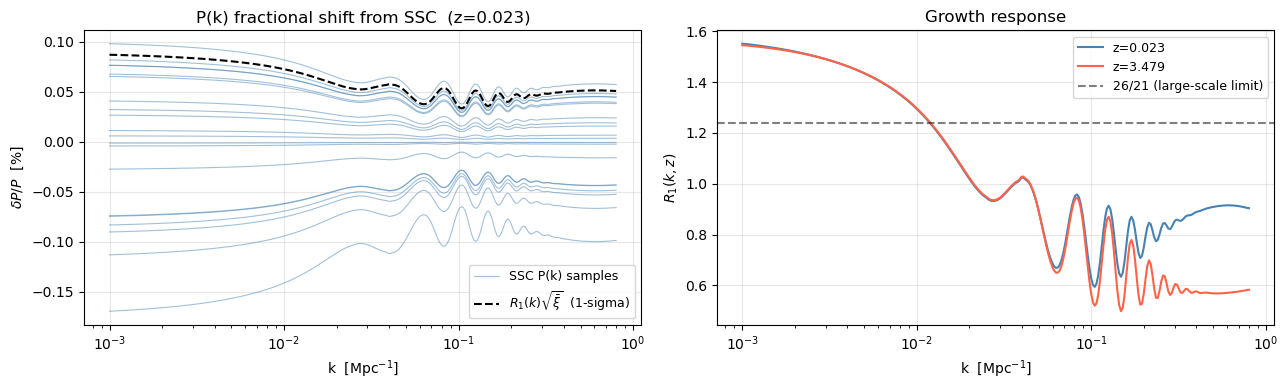

In [10]:
n_pk_ssc = 20
pk_ssc_samples, pk_fid_dict, delta_b_pk, R1 = sample_pk_ssc(
    variables.cosmo, variables.redshifts, xi_bar,
    n_samples=n_pk_ssc, seed=seed,
)

# Show P(k) fractional perturbation: R1(k) * delta_b for one sample
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
z0 = variables.redshifts[0]
for i_s, pk_s in enumerate(pk_ssc_samples):
    frac = pk_s[float(z0)] / pk_fid_dict[float(z0)] - 1.0
    ax.semilogx(k, 100*frac, color='steelblue', alpha=0.5, lw=0.8,
                label='SSC P(k) samples' if i_s==0 else '')
ax.semilogx(k, 100*R1[0]*np.sqrt(xi_bar), 'k--', lw=1.5, label=r'$R_1(k)\sqrt{\bar{\xi}}$  (1-sigma)')
ax.set_xlabel(r'k  [Mpc$^{-1}$]')
ax.set_ylabel(r'$\delta P/P$  [%]')
ax.set_title(f'P(k) fractional shift from SSC  (z={z0:.3f})')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogx(k, R1[0], color='steelblue', lw=1.5, label=f'z={z0:.3f}')
ax.semilogx(k, R1[-1], color='tomato',    lw=1.5, label=f'z={variables.redshifts[-1]:.3f}')
ax.axhline(26/21, color='k', ls='--', alpha=0.5, label='26/21 (large-scale limit)')
ax.set_xlabel(r'k  [Mpc$^{-1}$]')
ax.set_ylabel(r'$R_1(k,z)$')
ax.set_title('Growth response')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [11]:
print(f'Running full LDT for {n_pk_ssc} SSC P(k) samples...')
l1_pk_ssc = []
sig2_pk_ssc = []
for i_s, pk_s in enumerate(pk_ssc_samples):
    l1_s, _, spt_s, sldt_s = run_ldt_pipeline(variables, pk_s)
    l1_pk_ssc.append(l1_s)
    sig2_pk_ssc.append(spt_s)
l1_pk_ssc   = np.array(l1_pk_ssc)
sig2_pk_ssc = np.array(sig2_pk_ssc)
print('Done.')

print(f'\nsigma2_pt fid  = {sigmasq_pt_fid:.4e}')
print(f'sigma2_pt std  = {np.std(sig2_pk_ssc):.4e}  ({100*np.std(sig2_pk_ssc)/sigmasq_pt_fid:.4f} %)')
print(f'\nL1 from P(k) SSC pipeline:')
print(f'  std(L1) = {np.std(l1_pk_ssc,axis=0).max():.4e}  ({100*np.std(l1_pk_ssc,axis=0).max()/l1_mean:.3f} %)')
print(f'  SSC analytic = {l1_std_ssc:.4e}  ({100*l1_std_ssc/l1_mean:.3f} %)')
print(f'  Ratio (pipeline/analytic) = {np.std(l1_pk_ssc,axis=0).max()/l1_std_ssc:.3f}  (should be ~1)')


Running full LDT for 20 SSC P(k) samples...
PT sigma2_kappa : 4.101021e-06
LDT sigma2_kappa : 3.605730e-06
Recal factor     : 0.879227
PT sigma2_kappa : 4.098460e-06
LDT sigma2_kappa : 3.603511e-06
Recal factor     : 0.879235
PT sigma2_kappa : 4.101869e-06
LDT sigma2_kappa : 3.606465e-06
Recal factor     : 0.879225
PT sigma2_kappa : 4.102231e-06
LDT sigma2_kappa : 3.606779e-06
Recal factor     : 0.879224
PT sigma2_kappa : 4.096726e-06
LDT sigma2_kappa : 3.602008e-06
Recal factor     : 0.879241
PT sigma2_kappa : 4.097961e-06
LDT sigma2_kappa : 3.603078e-06
Recal factor     : 0.879237
PT sigma2_kappa : 4.100684e-06
LDT sigma2_kappa : 3.605438e-06
Recal factor     : 0.879228
PT sigma2_kappa : 4.099838e-06
LDT sigma2_kappa : 3.604705e-06
Recal factor     : 0.879231
PT sigma2_kappa : 4.100408e-06
LDT sigma2_kappa : 3.605199e-06
Recal factor     : 0.879229
PT sigma2_kappa : 4.098816e-06
LDT sigma2_kappa : 3.603819e-06
Recal factor     : 0.879234
PT sigma2_kappa : 4.102115e-06
LDT sigma2_kapp

## 6b. $C_\ell$ samples, L1 samples, and $\sigma^2_\kappa$ self-consistency

For each $P(k)$ realisation (N-modes scatter from `get_covariance`):
- **Panel 1**: $C_\ell$ via Limber $= \int d\chi\,(W/\chi)^2 P(k,z)$ — same formula as PyCCL `angular_cl`
- **Panel 2**: L1 integrand $|\kappa|P(\kappa)$ from full LDT run
- **Panel 3**: Scatter of $\sigma^2_\kappa$ from $C_\ell$ (power-spectrum route) vs from PDF moments
  $(\int(\kappa-\mu)^2 P\,\mathrm{d}\kappa)$ — both from the **same** $P(k)$ sample, should lie on 1:1


Running C_ell (PyCCL Pk2D) + LDT for 15 combined CV+SSC samples...
  [ 1/15]  sig2_cell=4.4215e-06  sig2_pdf=3.5862e-06  delta_b=-1.117e-04
  [ 2/15]  sig2_cell=4.3681e-06  sig2_pdf=3.6030e-06  delta_b=-6.423e-04
  [ 3/15]  sig2_cell=4.4289e-06  sig2_pdf=3.6112e-06  delta_b=4.976e-05
  [ 4/15]  sig2_cell=4.4383e-06  sig2_pdf=3.5945e-06  delta_b=-8.195e-04
  [ 5/15]  sig2_cell=4.4504e-06  sig2_pdf=3.6249e-06  delta_b=-5.748e-04
  [ 6/15]  sig2_cell=4.7795e-06  sig2_pdf=3.6303e-06  delta_b=-4.200e-04
  [ 7/15]  sig2_cell=4.5350e-06  sig2_pdf=3.5890e-06  delta_b=4.722e-04
  [ 8/15]  sig2_cell=4.4405e-06  sig2_pdf=3.6001e-06  delta_b=-2.029e-04
  [ 9/15]  sig2_cell=4.5279e-06  sig2_pdf=3.6094e-06  delta_b=-2.506e-04
  [10/15]  sig2_cell=4.8543e-06  sig2_pdf=3.6082e-06  delta_b=1.094e-03
  [11/15]  sig2_cell=5.1919e-06  sig2_pdf=3.6113e-06  delta_b=1.972e-04
  [12/15]  sig2_cell=4.5387e-06  sig2_pdf=3.6096e-06  delta_b=1.897e-04
  [13/15]  sig2_cell=4.2113e-06  sig2_pdf=3.5694e-06  delta_b=

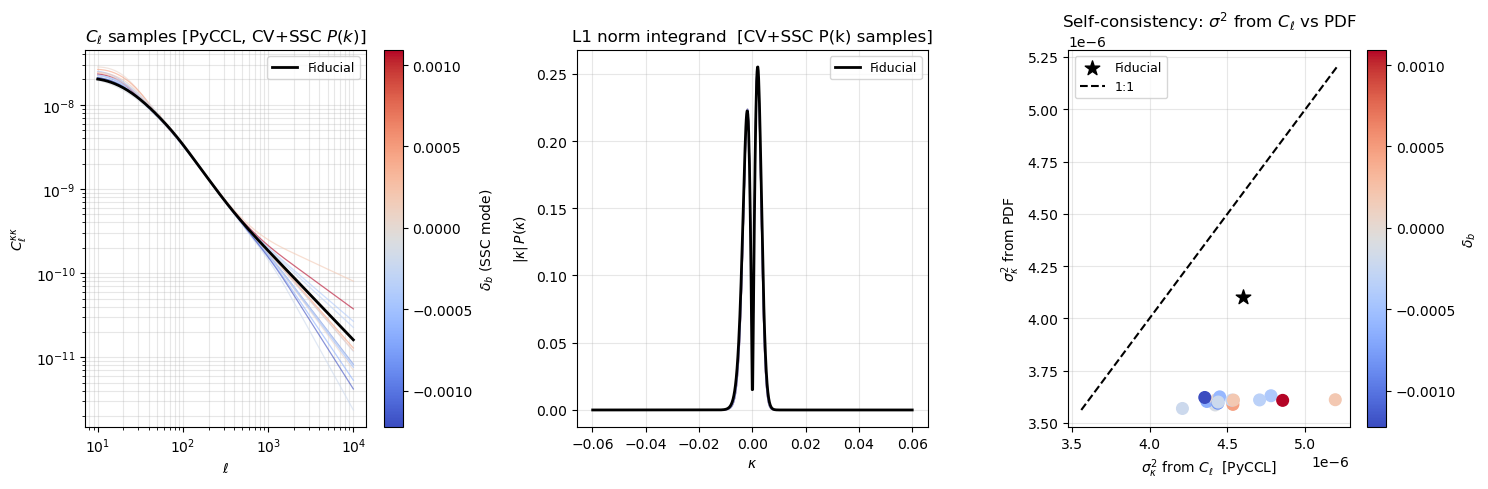

In [12]:
import pyccl as ccl
from wale.FilterFunctions import top_hat_filter, starlet_filter
from wale.VarianceCalculator import Variance as _Var
from wale.ComputePDF import computePDF as _cpdf
from wale.CovarianceMatrix import sample_pk_combined

# Draw combined CV+SSC P(k) samples
n_comb = 15
pk_comb_samples, pk_fid_dict, eps_samp, delta_b_samp, R1_arr = sample_pk_combined(
    variables.cosmo, variables.redshifts,
    xi_bar,
    n_samples=n_comb,
    seed=seed,
)

# Build PyCCL weak-lensing tracer from n(z)
_nz = np.loadtxt(nz_file)
_z_nz, _n_nz = _nz[:, 0], _nz[:, 1]
tracer = ccl.WeakLensingTracer(
    variables.cosmo.cosmoccl,
    dndz=(_z_nz, _n_nz),
    use_A_ia=False,
)

# ell grid and filter window
ell_grid  = np.logspace(1, 4, 300)
theta_rad = (theta1 / 60.0) * np.pi / 180.0
if filter_type == 'tophat':
    Wl = top_hat_filter(ell_grid, 2*theta_rad) - top_hat_filter(ell_grid, theta_rad)
else:
    Wl = starlet_filter(ell_grid, 2*theta_rad) - starlet_filter(ell_grid, theta_rad)

def make_pk2d(pk_dict):
    _k  = np.asarray(variables.cosmo.k, dtype=float)
    _zs = np.sort(np.asarray(variables.redshifts, dtype=float))[::-1]  # descending z
    _as = 1.0 / (1.0 + _zs)                                            # ascending a
    _pk = np.vstack([
        np.asarray(pk_dict[float(z)], dtype=float) for z in _zs
    ])
    return ccl.Pk2D(
        a_arr  = _as,
        lk_arr = np.log(_k),
        pk_arr = np.log(np.maximum(_pk, 1e-300)),
        is_logp= True,
    )

def sig2_from_cell(cell):
    return float(np.trapezoid(ell_grid * cell * Wl**2, ell_grid) / (2*np.pi))

def sig2_from_pdf(kappa, pdf):
    p  = pdf / np.trapezoid(pdf, kappa)
    mu = float(np.trapezoid(kappa * p, kappa))
    return float(np.trapezoid((kappa - mu)**2 * p, kappa))

# Loop: C_ell via PyCCL + LDT pipeline
cells_all  = []
sig2_cell  = []
sig2_pdf   = []
kappa_pdfs = []

print(f'Running C_ell (PyCCL Pk2D) + LDT for {n_comb} combined CV+SSC samples...')
for i, pk_s in enumerate(pk_comb_samples):
    pk2d = make_pk2d(pk_s)
    cs   = ccl.angular_cl(
        variables.cosmo.cosmoccl,
        tracer, tracer,
        ell_grid,
        p_of_k_a=pk2d,
        l_limber=-1,
    )
    cells_all.append(cs)
    sig2_cell.append(sig2_from_cell(cs))

    var_s  = _Var(variables.cosmo, filter_type=filter_type, pk=pk_s)
    sldt   = float(np.sum(
        variables.dchi * variables.lensingweights**2 * np.array([
            float(var_s.get_sig_slice(z_i, chi*variables.theta1_radian,
                                      chi*variables.theta2_radian))
            for z_i, chi in zip(variables.redshifts, variables.chis)
        ])
    ))
    variables.sigmasq_map = sldt
    variables.recal_value = 1.0
    variables.lambdas     = lambdas
    pobj = _cpdf(variables, var_s, plot_scgf=False)
    kv   = np.asarray(pobj.kappa_values)
    pv   = np.asarray(pobj.pdf_values)
    kappa_pdfs.append((kv, pv))
    sig2_pdf.append(sig2_from_pdf(kv, pv))
    print(f'  [{i+1:2d}/{n_comb}]  sig2_cell={sig2_cell[-1]:.4e}'
          f'  sig2_pdf={sig2_pdf[-1]:.4e}'
          f'  delta_b={delta_b_samp[i]:.3e}')

sig2_cell = np.array(sig2_cell)
sig2_pdf  = np.array(sig2_pdf)
cells_all = np.array(cells_all)

# Fiducial C_ell and sigma^2
pk2d_fid = make_pk2d(pk_fid_dict)
cell_fid = ccl.angular_cl(
    variables.cosmo.cosmoccl, tracer, tracer, ell_grid,
    p_of_k_a=pk2d_fid, l_limber=-1,
)
s2c_fid = sig2_from_cell(cell_fid)
s2p_fid = sig2_from_pdf(kappa_raw, pdf_raw)
print(f'\nFiducial  sig2_cell={s2c_fid:.4e}  sig2_pdf={s2p_fid:.4e}')
print(f'CV+SSC scatter  sig2_cell: {100*sig2_cell.std()/s2c_fid:.4f}%'
      f'  sig2_pdf: {100*sig2_pdf.std()/s2p_fid:.4f}%')

# 3-panel plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
norm_db   = (delta_b_samp - delta_b_samp.min()) / (delta_b_samp.max() - delta_b_samp.min() + 1e-30)
cmap      = plt.cm.coolwarm

# Panel 1: C_ell samples
ax = axes[0]
for i_s, cs in enumerate(cells_all):
    ax.loglog(ell_grid, cs, color=cmap(norm_db[i_s]), alpha=0.6, lw=0.9)
ax.loglog(ell_grid, cell_fid, color='k', lw=2, label='Fiducial')
sm = plt.cm.ScalarMappable(cmap=cmap,
     norm=plt.Normalize(delta_b_samp.min(), delta_b_samp.max()))
sm.set_array([])
plt.colorbar(sm, ax=ax, label=r'$\delta_b$ (SSC mode)')
ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$C_\ell^{\kappa\kappa}$')
ax.set_title(r'$C_\ell$ samples [PyCCL, CV+SSC $P(k)$]')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, which='both')

# Panel 2: L1 norm integrands
ax = axes[1]
for i_s, (kv, pv) in enumerate(kappa_pdfs):
    pn = pv / np.trapezoid(pv, kv)
    ax.plot(kv, np.abs(kv) * pn, color=cmap(norm_db[i_s]), alpha=0.6, lw=0.9)
pn_fid = pdf_raw / np.trapezoid(pdf_raw, kappa_raw)
ax.plot(kappa_raw, np.abs(kappa_raw) * pn_fid, color='k', lw=2, label='Fiducial')
ax.set_xlabel(r'$\kappa$')
ax.set_ylabel(r'$|\kappa|\,P(\kappa)$')
ax.set_title('L1 norm integrand  [CV+SSC P(k) samples]')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Panel 3: scatter sigma^2 from C_ell vs sigma^2 from PDF
ax = axes[2]
sc = ax.scatter(sig2_cell, sig2_pdf, c=delta_b_samp, cmap='coolwarm', s=70, zorder=5)
ax.scatter([s2c_fid], [s2p_fid], color='k', s=120, zorder=6, marker='*', label='Fiducial')
lo = min(sig2_cell.min(), sig2_pdf.min()) * 0.998
hi = max(sig2_cell.max(), sig2_pdf.max()) * 1.002
ax.plot([lo, hi], [lo, hi], 'k--', lw=1.5, label='1:1')
plt.colorbar(sc, ax=ax, label=r'$\delta_b$')
ax.set_xlabel(r'$\sigma^2_\kappa$ from $C_\ell$  [PyCCL]')
ax.set_ylabel(r'$\sigma^2_\kappa$ from PDF')
ax.set_title(r'Self-consistency: $\sigma^2$ from $C_\ell$ vs PDF')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cell_l1_consistency.png', dpi=120, bbox_inches='tight')
plt.show()


## 7. Noise vs survey area

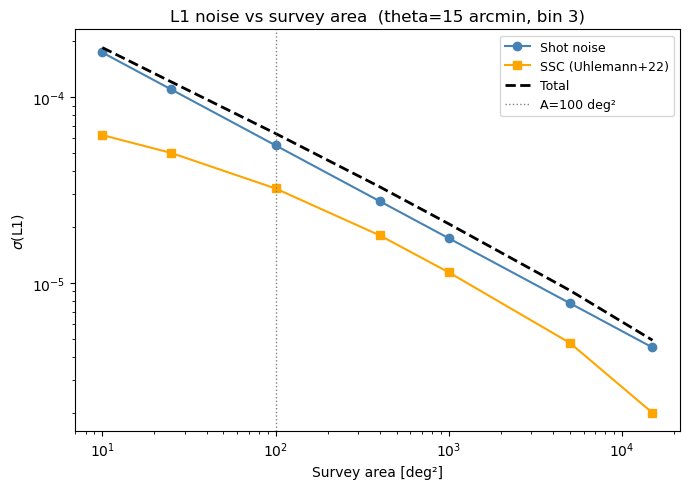

SSC/Shot ratio range: 0.359 – 0.655


In [12]:
areas = np.array([10., 25., 100., 400., 1000., 5000., 15000.])
stds_shot, stds_ssc = [], []
for A in areas:
    _, s_shot, _ = get_l1_estimator_variance(pdf_raw, kappa_raw, A, theta1)
    _, s_ssc, _, _ = get_l1_ssc_variance(
        pdf_raw, kappa_raw, sigmasq_pt_fid, A,
        variables.chis, variables.lensingweights, variables.redshifts,
        k, variables.cosmo.pnl, filter_type=filter_type, h=h,
    )
    stds_shot.append(s_shot)
    stds_ssc.append(s_ssc)
stds_shot = np.array(stds_shot)
stds_ssc  = np.array(stds_ssc)
stds_tot  = np.sqrt(stds_shot**2 + stds_ssc**2)

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(areas, stds_shot, 'o-', color='steelblue',  label='Shot noise')
ax.loglog(areas, stds_ssc,  's-', color='orange',     label='SSC (Uhlemann+22)')
ax.loglog(areas, stds_tot,  'k--', lw=2,               label='Total')
ax.axvline(A_survey_deg2, color='gray', ls=':', lw=1, label=f'A={A_survey_deg2:.0f} deg²')
ax.set_xlabel('Survey area [deg²]')
ax.set_ylabel(r'$\sigma$(L1)')
ax.set_title(f'L1 noise vs survey area  (theta={theta1} arcmin, bin {tomo_bin})')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Crossover
from scipy.interpolate import interp1d
try:
    ratio_arr = stds_ssc / stds_shot
    if ratio_arr[0] < 1 < ratio_arr[-1] or ratio_arr[-1] < 1 < ratio_arr[0]:
        cross = float(interp1d(ratio_arr, areas)(1.0))
        print(f'SSC dominates for A > {cross:.0f} deg2')
    else:
        print(f'SSC/Shot ratio range: {ratio_arr.min():.3f} – {ratio_arr.max():.3f}')
except Exception as e:
    print(e)


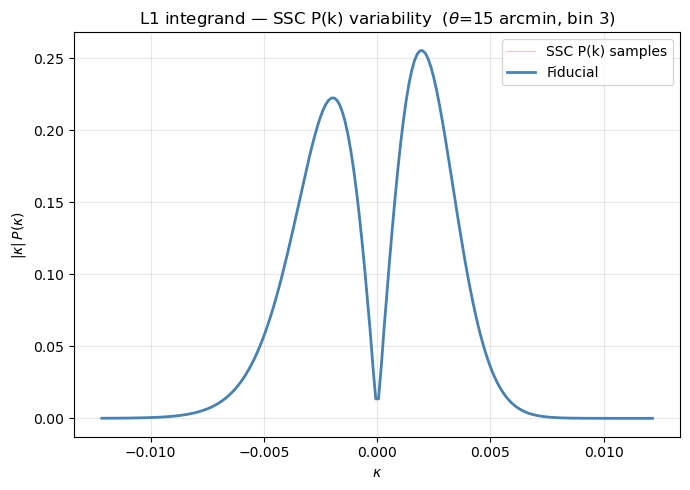

In [13]:
# Convert SNR grid to kappa using fiducial sigma
kappa_axis = snr * np.sqrt(sigmasq_pt_fid)                                                             
                                                                                                        
plt.figure(figsize=(7, 5))                                                                             
for i_s in range(n_pk_ssc):                                                                            
    plt.plot(kappa_axis, l1_pk_ssc[i_s], color='orange', alpha=0.5, lw=0.8,                            
            label='SSC P(k) samples' if i_s == 0 else '')                                             
plt.plot(kappa_axis, l1_fid, color='steelblue', lw=2, label='Fiducial')                                
plt.xlabel(r'$\kappa$')                                                                                
plt.ylabel(r'$|\kappa|\,P(\kappa)$')                                                                   
plt.title(f'L1 integrand — SSC P(k) variability  ($\\theta$={theta1} arcmin, bin {tomo_bin})')         
plt.legend()                                                                                           
plt.grid(True, alpha=0.3)                                                                              
plt.tight_layout()                                                                                     
plt.show()

Text(0, 0.5, '$|\\kappa|\\,P(\\kappa)$')

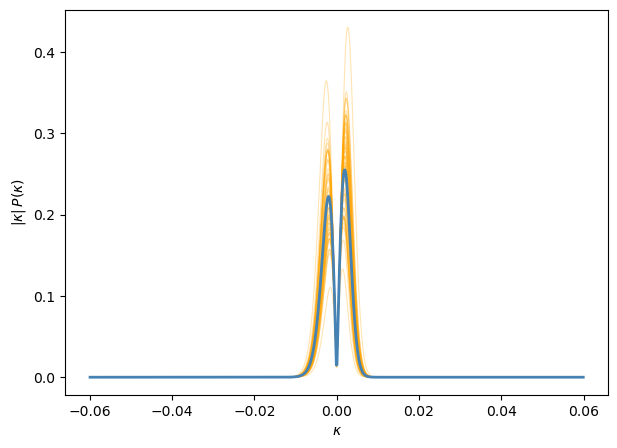

In [14]:
# Plot SSC-shifted L1 integrands using delta_b from sample_l1_ssc (section 4)                          
# For each realization: P_n(kappa) = P_fid(kappa - delta_b)                                            
# L1 integrand: |kappa| * P_n(kappa)        
                                        
p_norm = pdf_raw / np.trapezoid(pdf_raw, kappa_raw)
                                                                                                        
fig, ax = plt.subplots(figsize=(7, 5))      
                                                                                                        
# fiducial      
ax.plot(kappa_raw, np.abs(kappa_raw) * p_norm, color='steelblue', lw=2,                                
        label='Fiducial', zorder=5)         
                                                                                                        
# SSC-shifted curves (use delta_b already drawn in section 4)
n_show = min(50, len(delta_b))   
l1_shifted_samples = []                                                                      
for i_s in range(n_show):                                                                              
    db = delta_b[i_s]                                                                                  
    p_shifted = np.interp(kappa_raw - db, kappa_raw, p_norm, left=0.0, right=0.0)    
    l1_shifted = np.abs(kappa_raw) * p_shifted   
    l1_shifted_samples.append(l1_shifted)               
    ax.plot(kappa_raw, l1_shifted,                                                  
            color='orange', alpha=0.3, lw=0.8,
            label='SSC realisations' if i_s == 0 else '')                                              
                                                                                                        
ax.set_xlabel(r'$\kappa$')                                                                             
ax.set_ylabel(r'$|\kappa|\,P(\kappa)$')                                                                


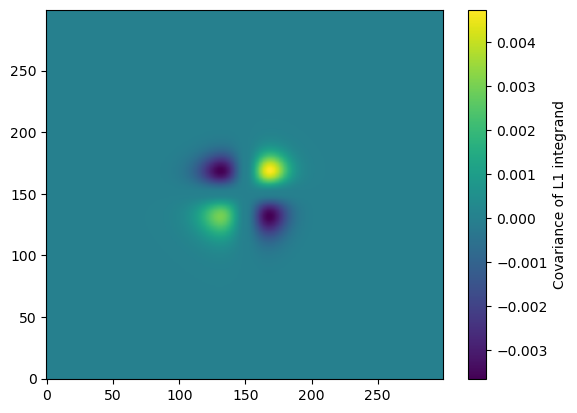

In [15]:
l1_shifted_samples = np.array(l1_shifted_samples)
cov = np.cov(l1_shifted_samples, rowvar=False)
plt.imshow(cov[250:550, 250:550], origin='lower', aspect='auto', vmin = cov.min(), vmax=cov.max())
plt.colorbar(label='Covariance of L1 integrand')